Plotting dataset 2000-2025 - periods 4 months
Plotting dataset 2000-2025 - periods 6 months
Plotting dataset 2000-2025 - periods 1 year
Plotting dataset 2000-2025 - periods 2 years


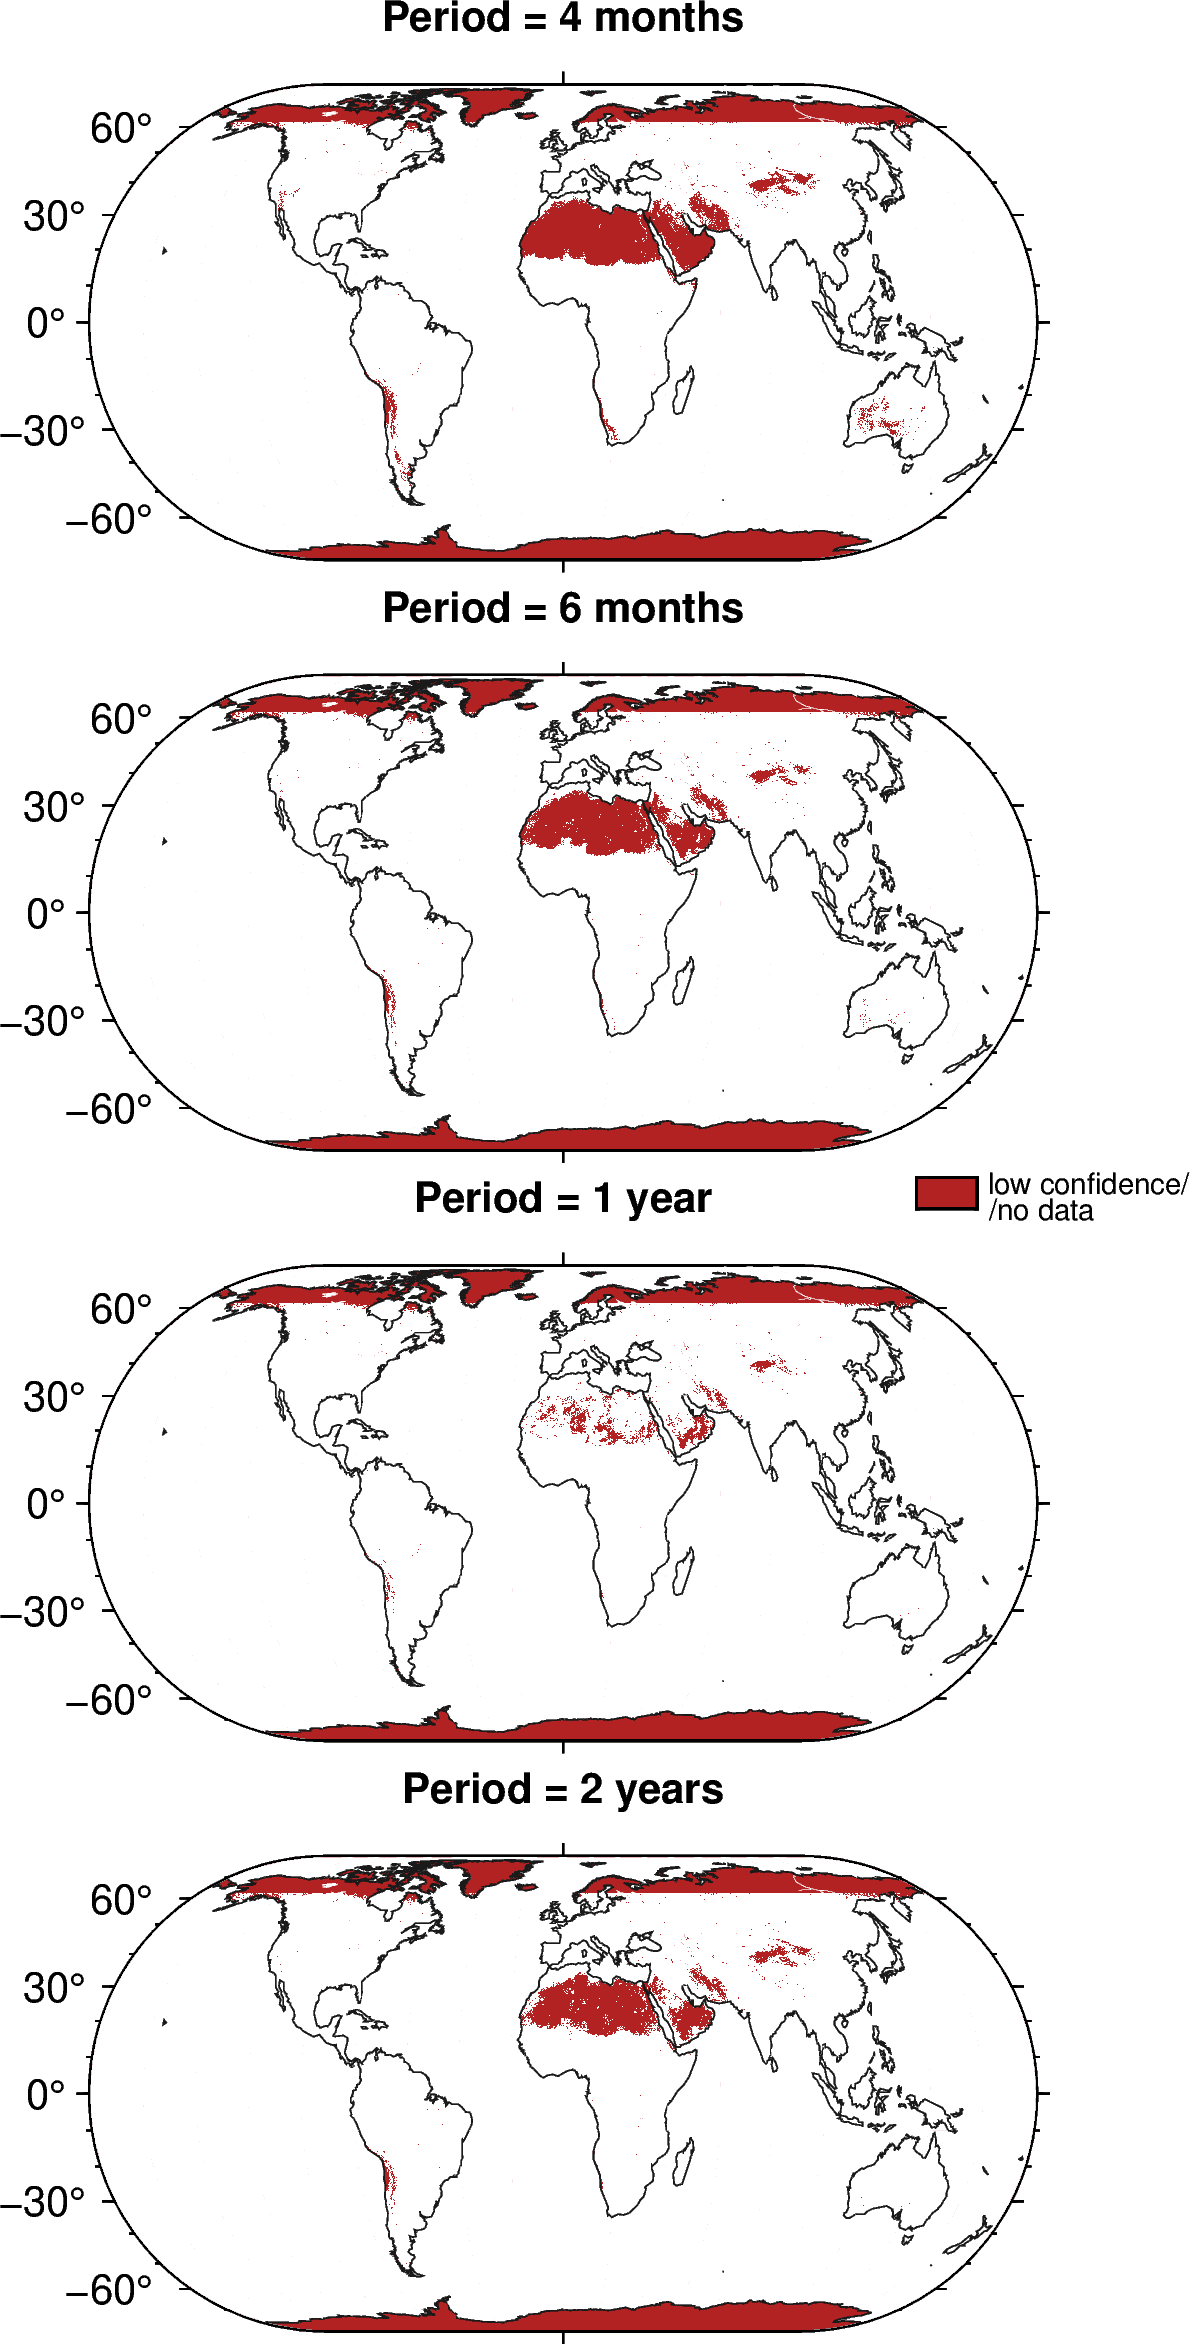

   latitude  longitude
0    89.975   -179.975
1    89.975   -179.925
2    89.975   -179.875
3    89.975   -179.825
4    89.975   -179.775
   latitude  area_per_pixel_m2
0    89.975       13487.370964
1    89.925       40462.102619
2    89.875       67436.803459
3    89.825       94411.452948
4    89.775      121386.030534
   latitude  longitude  area_per_pixel_m2
0    89.975   -179.975       13487.370964
1    89.975   -179.925       13487.370964
2    89.975   -179.875       13487.370964
3    89.975   -179.825       13487.370964
4    89.975   -179.775       13487.370964
          latitude  longitude  area_per_pixel_m2
25919995   -89.975    179.775       13487.370964
25919996   -89.975    179.825       13487.370964
25919997   -89.975    179.875       13487.370964
25919998   -89.975    179.925       13487.370964
25919999   -89.975    179.975       13487.370964


In [1]:
import xarray as xr
import pygmt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import import_ipynb
import numpy as np
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter, FuncFormatter
import geopandas as gpd
from matplotlib.patches import Rectangle


# import confidence masks, power grids, etc
from confidence_mask import summary_masks as masks_dictionary # masks dictionary
from figures_paper_input_data import power_diff_nor_dict as delta_norm_power, power_diff_dict as delta_power # power difference dictionaries
from area_per_pixel import area_da as area_per_pixel # area per pixel dataarray

# Set global font to Helvetica
plt.rcParams['font.family'] = 'Helvetica'  # Set global font to Helvetica

# Figure 1: 
$\Delta\phi_{norm}$ (Delta normalised power for 4 different power windows). 

The $\Delta\phi_{norm}$ global grid data is produced and imported from figures_paper_input_data and all the previous scripts. However, grids of greening and browning for 6-month, 1-year and 2-year cycle are akso avalable to download here: https://figshare.com/s/219d49f198915cd2b37c. 

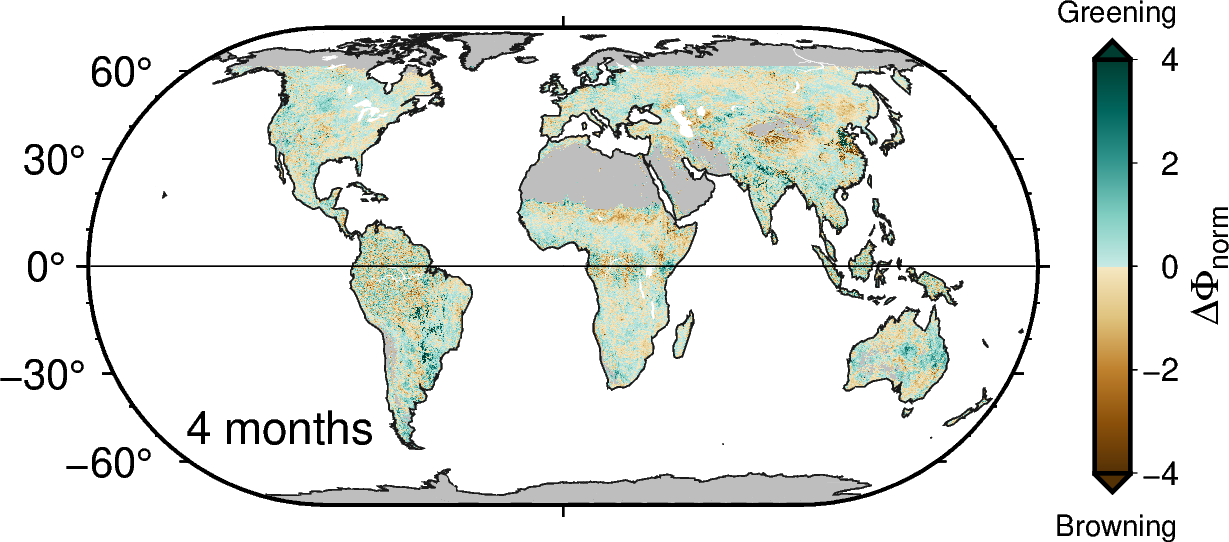

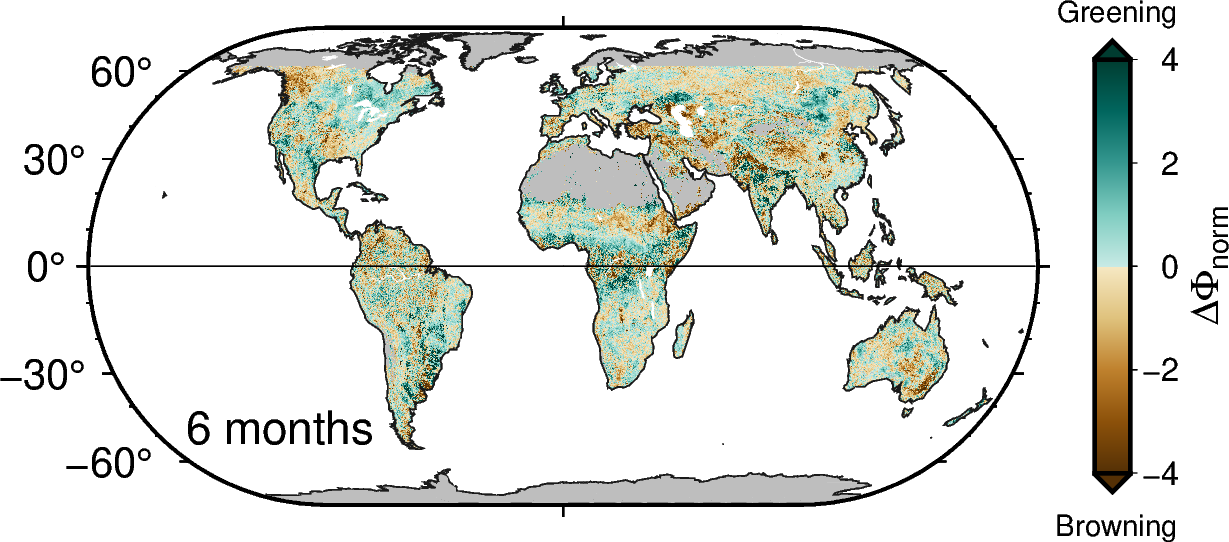

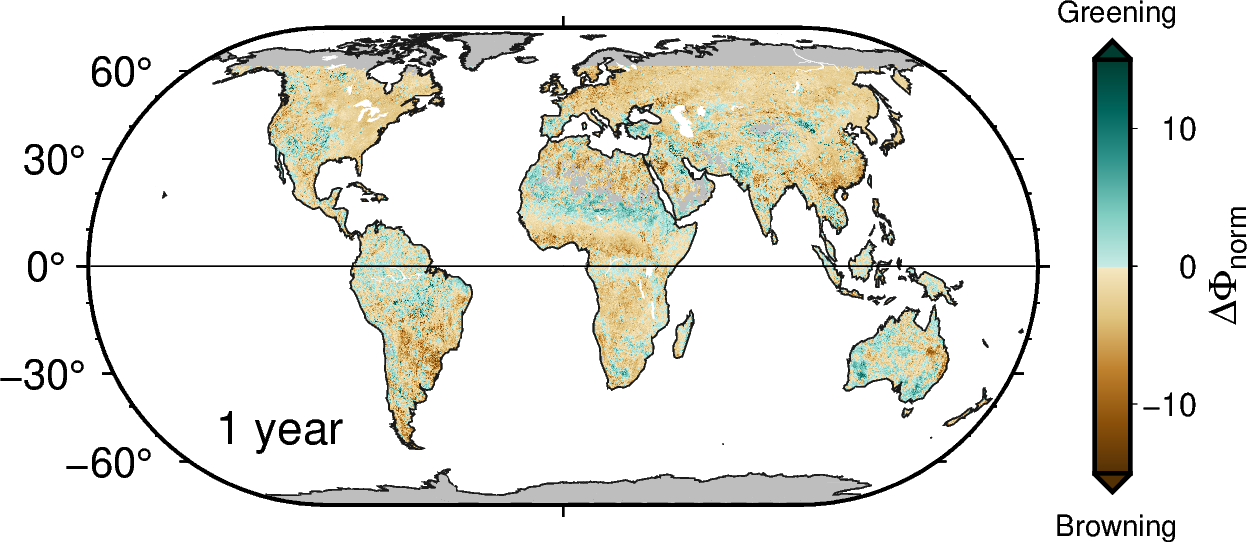

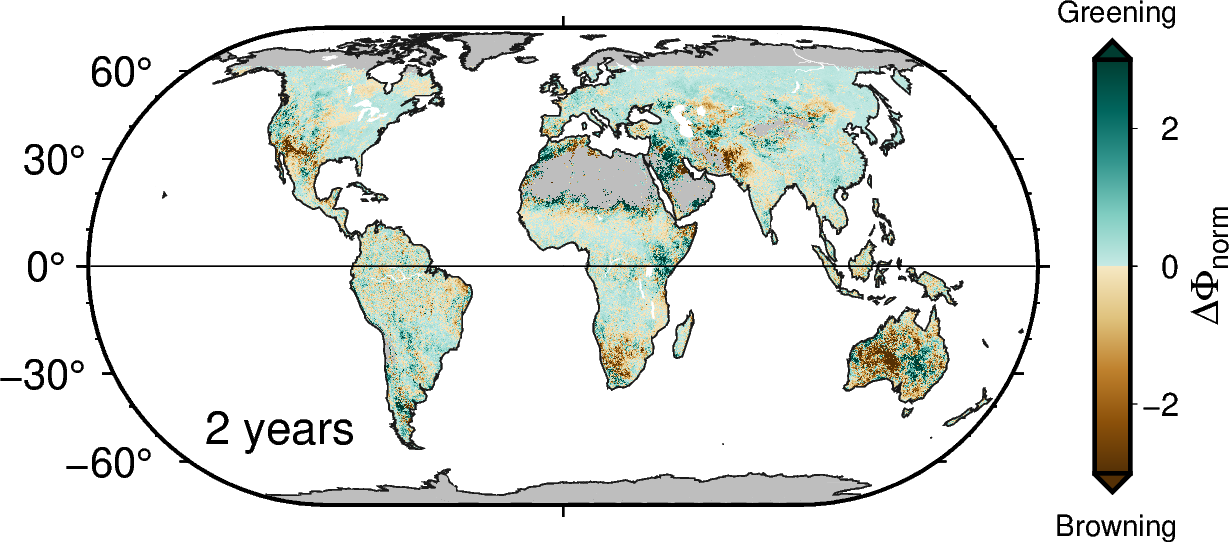

In [3]:
# visualise using a loop
for i, (label, grid) in enumerate(delta_norm_power.items()):
    fig = pygmt.Figure()
    # camp for all periods except 1 yr
    cmap = "gmt-palettes/BrBG.cpt"
    if i == 3:
        cmap = "gmt-palettes/BrBG_-3_3.cpt"
    
    # mask data using the confidemce masks
    mask = masks_dictionary[label].astype(int)
    grid = grid.where(mask == 1)
    
    # position the plots in the right order
    if i == 2:
        cmap = "gmt-palettes/BrBG_15_-15.cpt"
        
    if i == 1 or i == 3:
         # Plot grid
        with pygmt.config(FONT_ANNOT="10p", MAP_FRAME_TYPE="plain", FORMAT_GEO_MAP="ddd", MAP_FRAME_PEN="2p"):
            fig.basemap(region="d", projection="Kf8c", frame=["Wsne", "y30f10", "x360"])
    else:
        # Plot grid
        with pygmt.config(FONT_ANNOT="10p", MAP_FRAME_TYPE="plain", FORMAT_GEO_MAP="ddd", MAP_FRAME_PEN="2p"):
            fig.basemap(region="d", projection="Kf8c", frame=["Wsne", "y30f10", "x360"])
    
    fig.coast(land="gray", area_thresh="0/0/1")
    fig.grdimage(grid=grid,  cmap=cmap, nan_transparent=True)
    
    # Add coastlines and zero line
    fig.coast(area_thresh="10000", shorelines="1/0.3p,gray10", water="white")
    fig.plot(x=[-179.9, 0], y=[0, 0], pen="0.2p,black")
    fig.plot(x=[0, 179.9], y=[0, 0], pen="0.2p,black")
    
    # add dinamic labels for each subplot
    fig.text(
        x=0, y=0,                # dummy placeholders
        text=f"{label}",
        font="11p,Helvetica,black",
        offset="-2.4c/-1.5c",     # shift label below map
        justify="CB", # center-bottom of the map area
        no_clip=True,  # allow text outside map area
    )
    # Add colorbar
    with pygmt.config(FONT_ANNOT="16p", FONT_LABEL="20p", FONT_TITLE="18p"):
        fig.colorbar(
            frame=["a+l@~D@~@~F@~@-norm@- "],
            position="JMR+o0.5c/0c+w3.5c/0.3c+e")
    
    # add greening and browning labels
    fig.text(
            x=0, y=0,                # dummy placeholders
            text="Greening",
            font="7p,Helvetica,black",
            offset="+5.2c/2.25c",     # shift label outside map (left/top)
            justify="TR", # top-right of the map area
            no_clip=True,  # allow text outside map area
        )
    fig.text(
            x=0, y=0,                # dummy placeholders
            text="Browning",
            font="7p,Helvetica,black",
            offset="+5.2c/-2.1c",     # shift label outside map (left/top)
            justify="TR", # top-right of the map area
            no_clip=True,  # allow text outside map area
        )
        
    # Show final figure
    fig.show()
    fig.savefig(f"maps_of_power/figure_S2_{label.replace(' ', '_')}.png", dpi=600, transparent=True)


In [4]:
# create a dictionary to hold masked data for futher pics
delta_norm_power_masked = {}

for i, (label, grid) in enumerate(delta_norm_power.items()):
    # mask data using the confidemce masks
    mask = masks_dictionary[label].astype(int)
    grid = grid.where(mask == 1)
    
    delta_norm_power_masked[label] = grid


# Figure 2
summary stats for 3 areas, above thropics, tropical region, and below tropics

In [46]:
classified_power = {}

# for each pixel on the grids, I want to classify them as either positive or negative difference
for i, (label, grid) in enumerate(delta_power.items()):
    
    # mask data using the confidemce masks
    mask = masks_dictionary[label].astype(int)
    grid = grid.where(mask == 1)

    # create a new array that has value 1 if positive difference, and value 0 if negative difference, nan otherwise
    classified_grid = xr.where(grid > 0, 1, xr.where(grid < 0, 0, np.nan))
    
    # save in dict
    classified_power[label] = classified_grid

In [47]:
# now I want to merge this information with the area per pixel dataarray
area_per_pixel = area_per_pixel.rename("area_per_pixel") # give a name to the dataarray so that when I merge I do not loose information

# first I mask the area as I did for the other grids
masked_areas = {}

# for each pixel on the grids, I want to classify them as either positive or negative difference
for i, (label, mask) in enumerate(masks_dictionary.items()):
    
    # mask data using the confidence masks
    mask = mask.astype(int)
    area = area_per_pixel.where(mask == 1)
    
    # save in dict
    masked_areas[label] = area
    
# then merge it with the classified power dict
classified_power_with_area = {}

for i, (label, classified_grid) in enumerate(classified_power.items()):
    
    # merge the classified grid with the masked area
    merged = xr.merge([classified_grid.rename("classified_power"), masked_areas[label].rename("area_per_pixel")])
    
    # save in dict
    classified_power_with_area[label] = merged

In [ ]:
# generate a dataframe of area of positives and negatives pixels
increase_decrease_area_data = []

for label, grid in classified_power_with_area.items():
  
  # sum areas
    positive_area = float(grid.where(grid["classified_power"] == 1)["area_per_pixel"].sum().compute())
    negative_area = float(grid.where(grid["classified_power"] == 0)["area_per_pixel"].sum().compute())

    increase_decrease_area_data.append({
        "Label": label,
        "Latitude_Band": "Global",
        "Positive_Area_m2": positive_area,
        "Negative_Area_m2": negative_area
    })

# create summary table  
increase_decrease_area_data_df = pd.DataFrame(increase_decrease_area_data)
print(increase_decrease_area_data_df)


# do the same for each latitude band
increase_decrease_data_lat_area = []

for label, grid in classified_power_with_area.items():
    # define latitude bands
    above_tropics = grid.where(grid.lat > 23.5, drop=True)
    tropics = grid.where((grid.lat >= -23.5) & (grid.lat <= 23.5), drop=True)
    below_tropics = grid.where(grid.lat < -23.5, drop=True)

    # compute counts for each region
    bands = {
        "62N - 23.5N": above_tropics,
        "23.5N - 23.5S": tropics,
        "23.5S - 60S": below_tropics
    }

    for band_name, band_data in bands.items():
        positive_area = float(band_data.where(band_data["classified_power"] == 1)["area_per_pixel"].sum().compute())
        negative_area = float(band_data.where(band_data["classified_power"] == 0)["area_per_pixel"].sum().compute())

        increase_decrease_data_lat_area.append({
            "Label": label,
            "Latitude_Band": band_name,
            "Positive_Area_m2": positive_area,
            "Negative_Area_m2": negative_area
        })

# make a dataframe
increase_decrease_data_lat_df_area = pd.DataFrame(increase_decrease_data_lat_area)
# print(increase_decrease_data_lat_df_area)

# append global data to lat band data
increase_decrease_data_lat_df_area = pd.concat([increase_decrease_area_data_df,increase_decrease_data_lat_df_area], ignore_index=True)
# print(increase_decrease_data_lat_df_area)



      Label Latitude_Band  Positive_Area_m2  Negative_Area_m2
0  4 months        Global      6.077139e+13      4.418155e+13
1  6 months        Global      6.045477e+13      4.772580e+13
2    1 year        Global      5.423118e+13      6.233162e+13
3   2 years        Global      6.932286e+13      4.018733e+13


In [49]:
# convert from m2 to hectares
def m2_to_hectares(area_m2):
    return area_m2 / 10000

increase_decrease_data_lat_df_area['Positive_Area_ha'] = increase_decrease_data_lat_df_area['Positive_Area_m2'].apply(m2_to_hectares)
increase_decrease_data_lat_df_area['Negative_Area_ha'] = increase_decrease_data_lat_df_area['Negative_Area_m2'].apply(m2_to_hectares)

In [50]:
print(increase_decrease_data_lat_df_area)

       Label  Latitude_Band  Positive_Area_m2  Negative_Area_m2  \
0   4 months         Global      6.077139e+13      4.418155e+13   
1   6 months         Global      6.045477e+13      4.772580e+13   
2     1 year         Global      5.423118e+13      6.233162e+13   
3    2 years         Global      6.932286e+13      4.018733e+13   
4   4 months    60N - 23.5N      2.821638e+13      2.269241e+13   
5   4 months  23.5N - 23.5S      2.638443e+13      1.744331e+13   
6   4 months    23.5S - 60S      6.170583e+12      4.045823e+12   
7   6 months    60N - 23.5N      2.750137e+13      2.499627e+13   
8   6 months  23.5N - 23.5S      2.719629e+13      1.760179e+13   
9   6 months    23.5S - 60S      5.757110e+12      5.127737e+12   
10    1 year    60N - 23.5N      2.409744e+13      3.317753e+13   
11    1 year  23.5N - 23.5S      2.507502e+13      2.313624e+13   
12    1 year    23.5S - 60S      5.058720e+12      6.017846e+12   
13   2 years    60N - 23.5N      3.707096e+13      1.622150e+1

In [51]:
# Create a mapping of old to new latitude band names
lat_rename = {
    "23.5N - 23.5S": "Tropics",
    "60N - 23.5N": "North",
    "23.5S - 60S": "South",
    "Global": "Global"
}
# Apply the mapping
increase_decrease_data_lat_df_area["Latitude_Band_Renamed"] = increase_decrease_data_lat_df_area["Latitude_Band"].map(lat_rename)

# calculate percentage based on total areas in each band
increase_decrease_data_lat_df_area["Total_Area_ha"] = increase_decrease_data_lat_df_area["Positive_Area_ha"] + increase_decrease_data_lat_df_area["Negative_Area_ha"]
increase_decrease_data_lat_df_area["Positive_Area_Percentage"] = (increase_decrease_data_lat_df_area["Positive_Area_ha"] / increase_decrease_data_lat_df_area["Total_Area_ha"]) * 100
increase_decrease_data_lat_df_area["Negative_Area_Percentage"] = (increase_decrease_data_lat_df_area["Negative_Area_ha"] / increase_decrease_data_lat_df_area["Total_Area_ha"]) * 100
increase_decrease_data_lat_df_area["Net_Change_Percentage"] = increase_decrease_data_lat_df_area["Positive_Area_Percentage"] - increase_decrease_data_lat_df_area["Negative_Area_Percentage"]

print(increase_decrease_data_lat_df_area)



       Label  Latitude_Band  Positive_Area_m2  Negative_Area_m2  \
0   4 months         Global      6.077139e+13      4.418155e+13   
1   6 months         Global      6.045477e+13      4.772580e+13   
2     1 year         Global      5.423118e+13      6.233162e+13   
3    2 years         Global      6.932286e+13      4.018733e+13   
4   4 months    60N - 23.5N      2.821638e+13      2.269241e+13   
5   4 months  23.5N - 23.5S      2.638443e+13      1.744331e+13   
6   4 months    23.5S - 60S      6.170583e+12      4.045823e+12   
7   6 months    60N - 23.5N      2.750137e+13      2.499627e+13   
8   6 months  23.5N - 23.5S      2.719629e+13      1.760179e+13   
9   6 months    23.5S - 60S      5.757110e+12      5.127737e+12   
10    1 year    60N - 23.5N      2.409744e+13      3.317753e+13   
11    1 year  23.5N - 23.5S      2.507502e+13      2.313624e+13   
12    1 year    23.5S - 60S      5.058720e+12      6.017846e+12   
13   2 years    60N - 23.5N      3.707096e+13      1.622150e+1

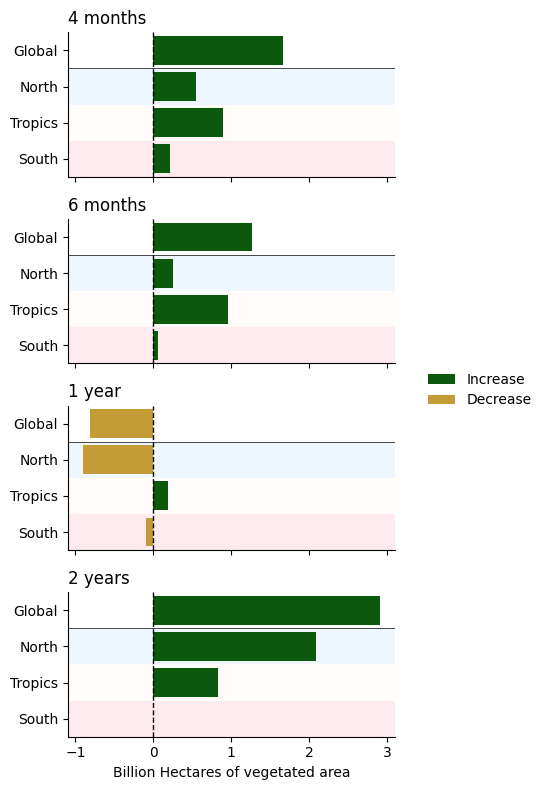

In [ ]:
# # sns.set_style("darkgrid", {"axes.facecolor": ".9"})

sns.reset_orig ()  # Reset to original matplotlib settings

# Compute net change
increase_decrease_data_lat_df_area["Net_Change_ha"] = increase_decrease_data_lat_df_area["Positive_Area_ha"] - increase_decrease_data_lat_df_area["Negative_Area_ha"]
# expressed in billions of hectares
increase_decrease_data_lat_df_area["Net_Change_ha_1e9"] = increase_decrease_data_lat_df_area["Net_Change_ha"] / 1e9
# netchange percentage of total area
increase_decrease_data_lat_df_area["Net_Change_Percentage"] = (increase_decrease_data_lat_df_area["Net_Change_ha"] / increase_decrease_data_lat_df_area["Total_Area_ha"]) * 100
# Create color-category column
increase_decrease_data_lat_df_area["Change_Type"] = increase_decrease_data_lat_df_area["Net_Change_ha"].apply(lambda x: "Increase" if x >= 0 else "Decrease")


# Assign colors manually
palette = {"Increase": "darkgreen", "Decrease": "goldenrod"}

# seaborn facet plot
g = sns.catplot(
    data=increase_decrease_data_lat_df_area,
    kind="bar",
    y="Latitude_Band_Renamed",
    x="Net_Change_ha_1e9",
    hue="Change_Type",
    palette=palette,
    col="Label",
    col_wrap=1,
    height=2,
    aspect=1.5, orient="h",
    sharey=True, sharex=True,
)
# Add zero line to each subplot
for ax in g.axes.flatten():
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.axhline(0.5, color="black", linewidth=0.5)
    # rectangle for north hemisphere
    north = Rectangle(
        xy=(ax.get_xlim()[0], 0.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#c7e2ff",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(north)
    
    # rectangle for tropics hemisphere
    tropics = Rectangle(
        xy=(ax.get_xlim()[0], 1.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#fff6ee",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(tropics)
    
    # rectangle for southern hemisphere
    south = Rectangle(
        xy=(ax.get_xlim()[0], 2.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#ffc0cb",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(south)
    
    
for ax, title in zip(g.axes.flatten(), increase_decrease_data_lat_df_area["Label"].unique()):
    # if ax == g.axes.flatten()[0] or ax == g.axes.flatten()[2]:
        ax.set_title(title, loc="left")
    # else:
        # ax.set_title(title, loc="right")
    
g.set_titles("")
g.set_xlabels("Billion Hectares of vegetated area")
g.set_ylabels("")
g.legend.set_title("")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")

plt.tight_layout()
plt.show()

# g.savefig("maps_of_power/figure_2_area_change_bars_vertical.png", dpi=3000, transparent=True)


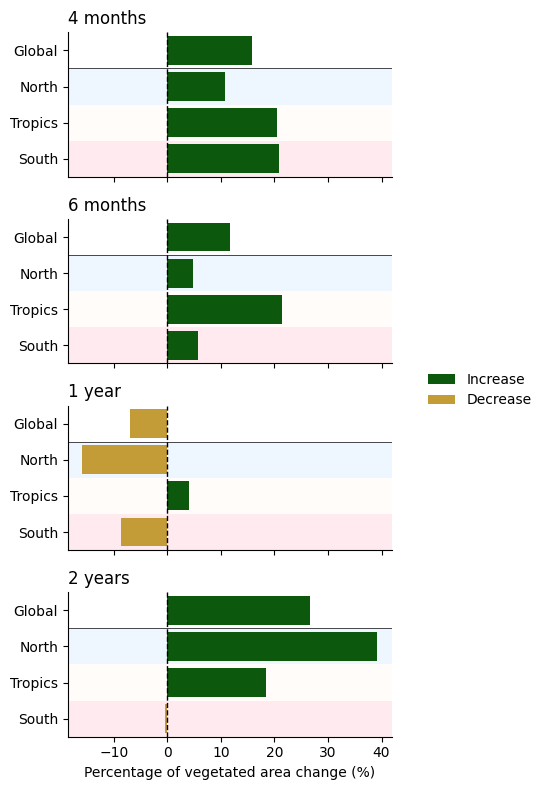

In [ ]:
sns.reset_orig ()  # Reset to original matplotlib settings

# Create color-category column
increase_decrease_data_lat_df_area["Change_Type"] = increase_decrease_data_lat_df_area["Net_Change_Percentage"].apply(lambda x: "Increase" if x >= 0 else "Decrease")


# Assign colors manually
palette = {"Increase": "darkgreen", "Decrease": "goldenrod"}

# seaborn facet plot
g = sns.catplot(
    data=increase_decrease_data_lat_df_area,
    kind="bar",
    y="Latitude_Band_Renamed",
    x="Net_Change_Percentage",
    hue="Change_Type",
    palette=palette,
    col="Label",
    col_wrap=1,
    height=2,
    aspect=1.5, orient="h",
    sharey=True, sharex=True,
)
# Add zero line to each subplot
for ax in g.axes.flatten():
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.axhline(0.5, color="black", linewidth=0.5)
    # rectangle for north hemisphere
    north = Rectangle(
        xy=(ax.get_xlim()[0], 0.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#c7e2ff",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(north)
    
    # rectangle for tropics hemisphere
    tropics = Rectangle(
        xy=(ax.get_xlim()[0], 1.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#fff6ee",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(tropics)
    
    # rectangle for southern hemisphere
    south = Rectangle(
        xy=(ax.get_xlim()[0], 2.5),   
        width=ax.get_xlim()[1] - ax.get_xlim()[0],  # full width of plot
        height=1,                   # rectangle height (adjust as needed)
        facecolor="#ffc0cb",
        alpha=0.3,
        edgecolor=None, zorder= 0)
    ax.add_patch(south)
    
    
for ax, title in zip(g.axes.flatten(), increase_decrease_data_lat_df_area["Label"].unique()):
    # if ax == g.axes.flatten()[0] or ax == g.axes.flatten()[2]:
        ax.set_title(title, loc="left")
    # else:
        # ax.set_title(title, loc="right")
    
g.set_titles("")
g.set_xlabels("Percentage of vegetated area change (%)")
g.set_ylabels("")
g.legend.set_title("")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")

plt.tight_layout()
plt.show()

# g.savefig("maps_of_power/figure_2_area_change_bars_percentage.png", dpi=600, transparent=True)
